# **1. Data-Driven Prioritization of Rare Diseases Using Orphadata**

**CAPB352 Business Data Analytics Project**

Project Overview:

Rare diseases are difficult to analyse because the data is large, complex, and often incomplete. It can also be challenging to identify which diseases may require more research attention or further investigation. Data analytics methods can help organise and explore rare disease information more effectively.

This notebook presents the Python analysis stage of the project after the SQL data integration process completed in DBeaver. The analysis uses the Orphadata summary dataset and applies different analytical techniques to explore patterns and relationships between diseases.

The workflow includes:
- Data cleaning and validation
- Exploratory Data Analysis
- Feature engineering
- Clustering techniques
- Anomaly detection
- Supporting regression analysis

The main aim of the analysis is to develop a data-based framework which could be applied to support rare disease prioritization and exploration.

# **2. Importing Libraries**

The following libraries are used for data processing, visualisation, clustering, validation, and machine learning tasks and to support the analytical workflow for the project.

In [7]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import skew

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25
})

print("Libraries imported successfully.")

Libraries imported successfully.


# **3. Loading Dataset**

I have imported the dataset directly from the GitHub repository, it contains the integrated rare disease summary dataset prepared using SQL.

In [8]:
url = "https://raw.githubusercontent.com/Jivaish/Rare-diseases/main/Data/Rare_diseases_summary.csv"

df = pd.read_csv(url)

df.head()

,OrphaCode,Name,DisorderGroup,gene_count,onset_count,inheritance_count,avg_prevalence
0,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...,Disorder,1,1,1,1.355833
1,6,3-methylcrotonyl-CoA carboxylase deficiency,Disorder,2,1,1,1.535000
2,7,3C syndrome,Disorder,4,1,1,12.500000
3,8,"47,XYY syndrome",Disorder,0,1,1,16.025000
4,9,Tetrasomy X syndrome,Disorder,0,1,1,25.000000


In [9]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (11456, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11456 entries, 0 to 11455
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrphaCode          11456 non-null  int64  
 1   Name               11456 non-null  object 
 2   DisorderGroup      11456 non-null  object 
 3   gene_count         11456 non-null  int64  
 4   onset_count        11456 non-null  int64  
 5   inheritance_count  11456 non-null  int64  
 6   avg_prevalence     6443 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 626.6+ KB


# **4. Initial Data Checks**



In [10]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate OrphaCode values:", df.duplicated(subset="OrphaCode").sum())
print("Duplicate full rows:", df.duplicated().sum())

Missing values:


,0
OrphaCode,0
Name,0
DisorderGroup,0
gene_count,0
onset_count,0
inheritance_count,0
avg_prevalence,5013



Duplicate OrphaCode values: 0
Duplicate full rows: 0


The output shows there is no duplicate records or duplicate OrphaCode values present jn the dataset which indicates that the SQL was done correctly. However, 5013 missing values can be seen in the avg_prevalence column. This suggests that prevalence information is not available for all rare diseases in the dataset and will need to be handled during the data cleaning stage.

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrphaCode,11456.0,NaN,NaN,NaN,212643.364787,205123.850994,5.0,57631.75,139460.5,317440.75,718255.0
Name,11456,11456,Developmental delay-facial dysmorphism-Blaschk...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DisorderGroup,11456,3,Disorder,7441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene_count,11456.0,NaN,NaN,NaN,0.72809,2.658769,0.0,0.0,0.0,1.0,114.0
onset_count,11456.0,NaN,NaN,NaN,0.64368,0.478932,0.0,0.0,1.0,1.0,1.0
inheritance_count,11456.0,NaN,NaN,NaN,0.64368,0.478932,0.0,0.0,1.0,1.0,1.0
avg_prevalence,6443.0,NaN,NaN,NaN,15.797329,182.028565,0.0,0.027581,2.0,8.5,10000.0


The summary statistics show that most diseases have relatively low values for gene count and prevalence, while a small number of diseases contain extremely large values. For example, the median value of gene_count is 0, while the maximum value reaches 114. Similarly, the median value of avg_prevalence is 2, but the maximum value reaches 10,000. This indicates that the dataset is highly skewed and will require transformation and scaling before clustering and modelling.

# **5. Data Cleaning**

In [12]:
df["has_prevalence_data"] = df["avg_prevalence"].notna().astype(int)
df["avg_prevalence"] = df["avg_prevalence"].fillna(0)

numeric_cols = ["gene_count", "onset_count", "inheritance_count", "avg_prevalence"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print("Missing values after cleaning:")
df.isnull().sum()

Missing values after cleaning:


,0
OrphaCode,0
Name,0
DisorderGroup,0
gene_count,0
onset_count,0
inheritance_count,0
avg_prevalence,0
has_prevalence_data,0


Here I have handled the missing values in all the column including avg_prevalence column. Now the dataset contains no missing values so it is ready to be used safely for clustering, feature engineering, and machine learning analysis.

# **6. Exploratory Data Analysis**

In [13]:
eda_summary = df[numeric_cols].describe().T
eda_summary["skewness"] = df[numeric_cols].apply(skew)

eda_summary.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness
gene_count,11456.0,0.728,2.659,0.0,0.0,0.0,1.0,114.0,18.155
onset_count,11456.0,0.644,0.479,0.0,0.0,1.0,1.0,1.0,-0.600
inheritance_count,11456.0,0.644,0.479,0.0,0.0,1.0,1.0,1.0,-0.600
avg_prevalence,11456.0,8.885,136.731,0.0,0.0,0.0,2.5,10000.0,64.572


The EDA summary confirms that the dataset is highly skewed, especially for gene_count and avg_prevalence. The skewness value for gene_count is 18.155, while avg_prevalence shows an extremely high skewness of 64.572. In addition, the median values for both variables are 0, while the maximum values reach 114 and 10,000 respectively. This indicates that most diseases contain low values, while a small number of diseases behave as extreme outliers. Therefore, transformation and scaling are necessary before clustering and modelling.

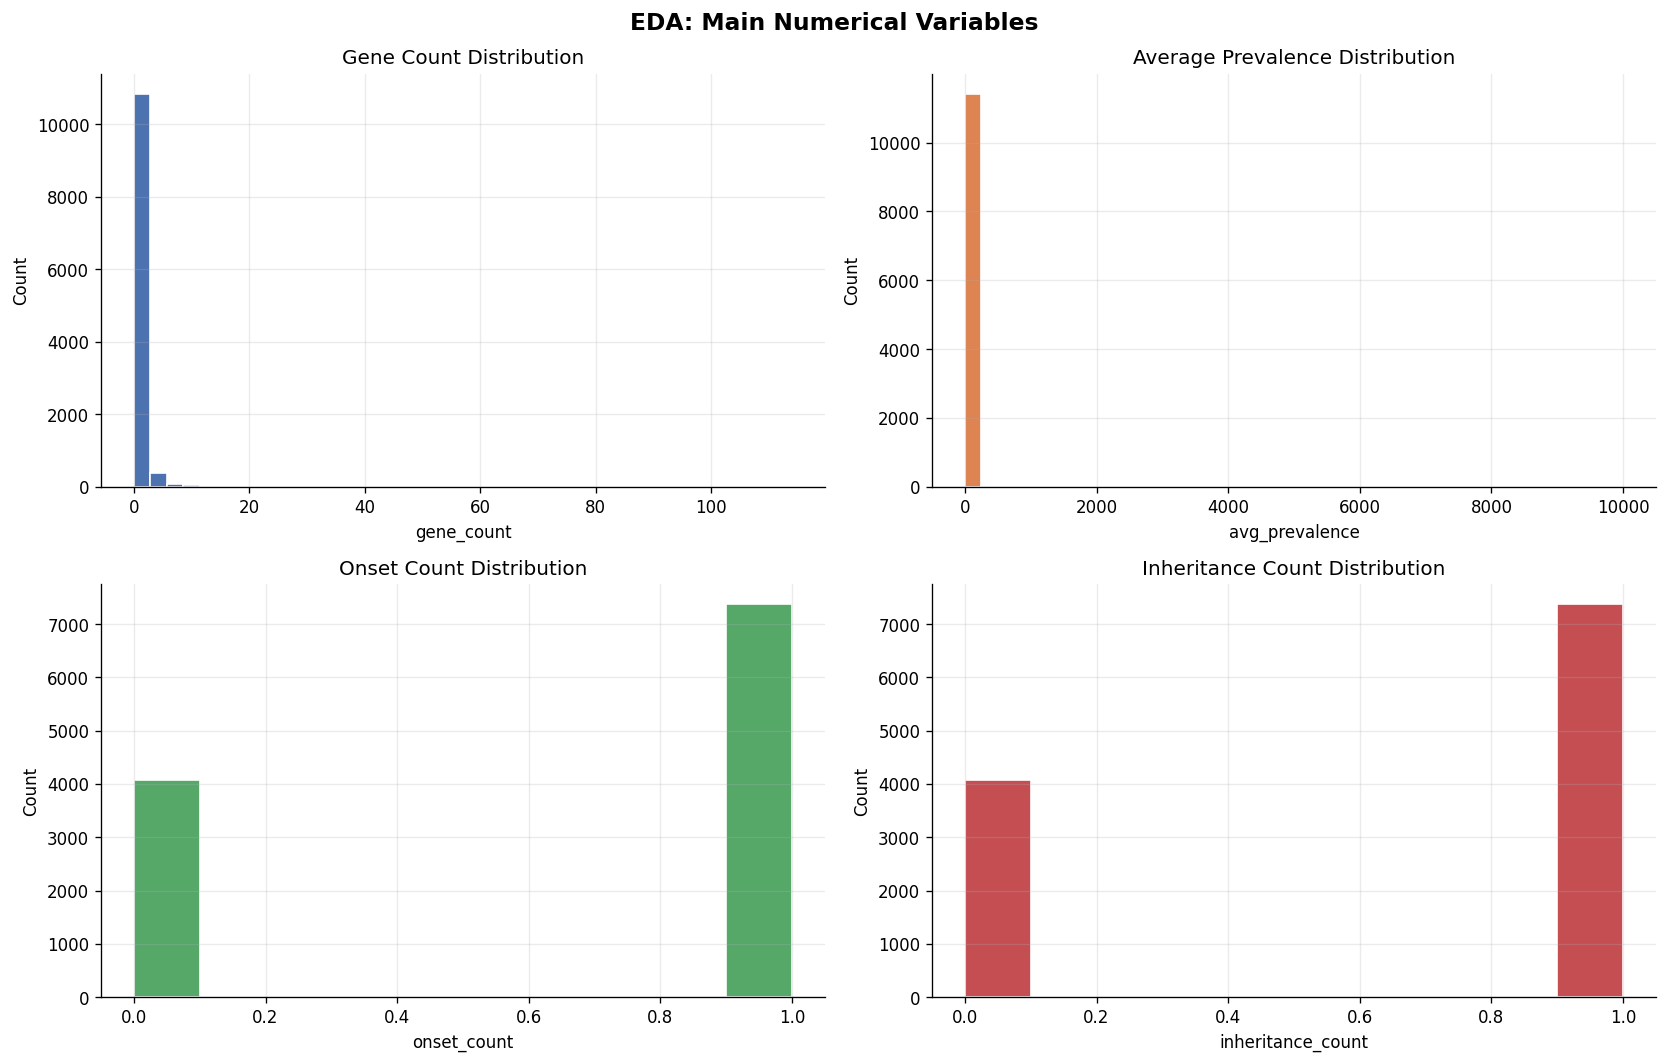

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("EDA: Main Numerical Variables", fontsize=14, fontweight="bold")

axes[0, 0].hist(df["gene_count"], bins=40, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Gene Count Distribution")
axes[0, 0].set_xlabel("gene_count")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df["avg_prevalence"], bins=40, color="#DD8452", edgecolor="white")
axes[0, 1].set_title("Average Prevalence Distribution")
axes[0, 1].set_xlabel("avg_prevalence")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(df["onset_count"], bins=10, color="#55A868", edgecolor="white")
axes[1, 0].set_title("Onset Count Distribution")
axes[1, 0].set_xlabel("onset_count")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(df["inheritance_count"], bins=10, color="#C44E52", edgecolor="white")
axes[1, 1].set_title("Inheritance Count Distribution")
axes[1, 1].set_xlabel("inheritance_count")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_main_distributions.png", bbox_inches="tight")
plt.show()

The graph confirms the imbalance in the dataset. Most diseases are concentrated around very low values for gene_count and avg_prevalence, while only a small number of diseases contain extremely high values. The distributions are heavily right-skewed, especially for prevalence.

The onset_count and inheritance_count variables are mostly binary, with values concentrated around 0 and 1. This indicates that these variables contain limited numerical variation compared to prevalence and gene-related features.

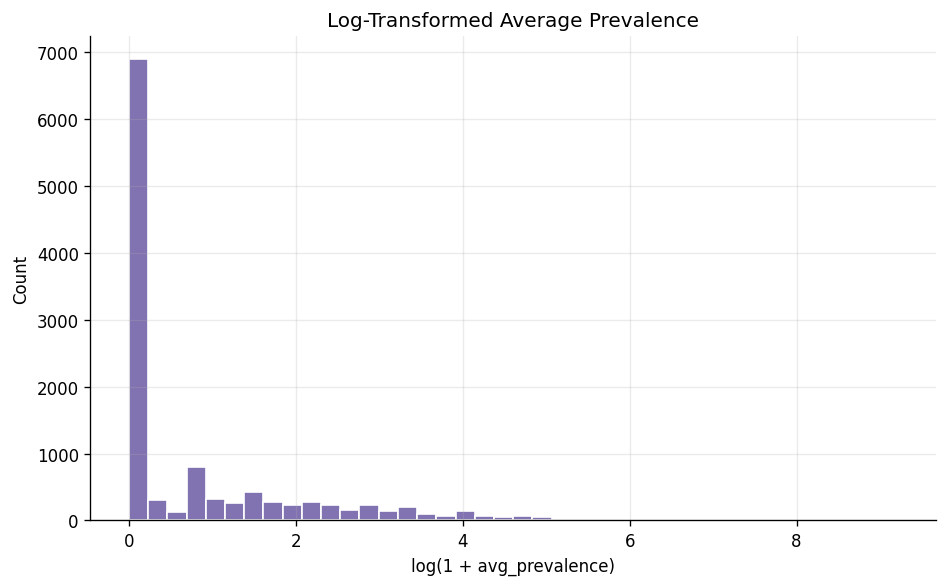

In [15]:
df["log_avg_prevalence"] = np.log1p(df["avg_prevalence"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_avg_prevalence"], bins=40, color="#8172B2", edgecolor="white")
plt.title("Log-Transformed Average Prevalence")
plt.xlabel("log(1 + avg_prevalence)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("log_prevalence_distribution.png", bbox_inches="tight")
plt.show()

I applied the log transformation so that the distribution of avg_prevalence becomes more compressed and less extreme compared to the original distribution. The data is still right-skewed but the transformation reduces the impact of very large prevalence values and makes the variable more suitable for clustering and machine learning analysis. This also helps prevent extreme outliers from dominating the models.

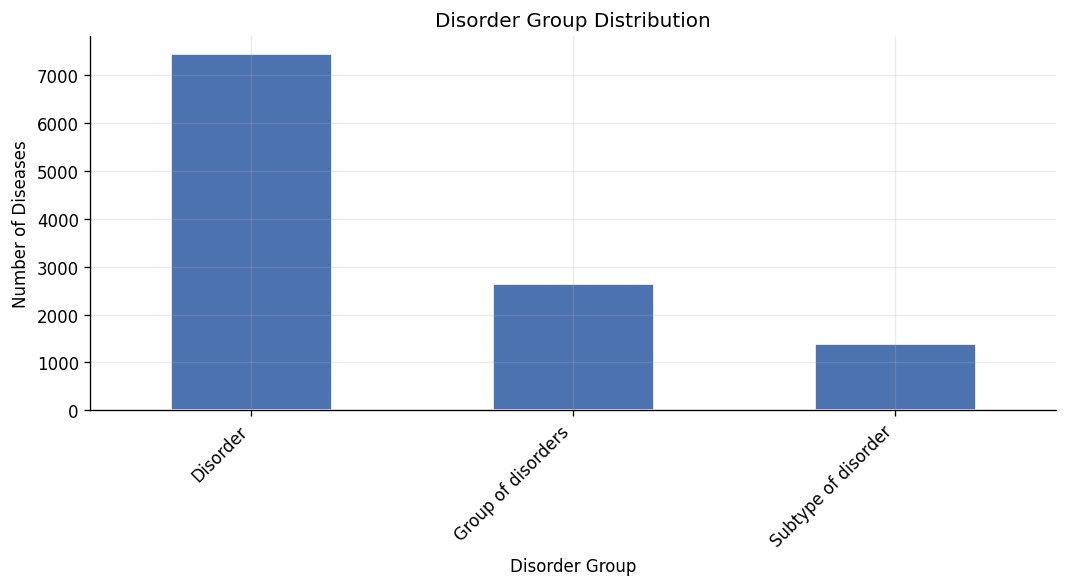

In [16]:
plt.figure(figsize=(9, 5))
df["DisorderGroup"].value_counts().plot(kind="bar", color="#4C72B0", edgecolor="white")
plt.title("Disorder Group Distribution")
plt.xlabel("Disorder Group")
plt.ylabel("Number of Diseases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("disorder_group_distribution.png", bbox_inches="tight")
plt.show()

The graph shows that there are large number of disorders records compared to Group of disorders and Subtype of disorder. This indicates that the dataset mainly focuses on individual rare diseases rather than broader disease classifications. The imbalance between categories should also be considered during clustering and interpretation because most analytical patterns will be influenced by the dominant Disorder group.

In [17]:
prevalence_coverage = (
    df.groupby("DisorderGroup")["has_prevalence_data"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "total_diseases",
        "sum": "with_prevalence",
        "mean": "coverage_rate"
    })
    .sort_values("total_diseases", ascending=False)
)

prevalence_coverage["coverage_rate"] = (prevalence_coverage["coverage_rate"] * 100).round(2)
prevalence_coverage

,total_diseases,with_prevalence,coverage_rate
DisorderGroup,,,
Disorder,7441,5548,74.56
Group of disorders,2633,318,12.08
Subtype of disorder,1382,577,41.75


The prevalence data is much more complete for individual diseases than for broader disease categories. For example, the Disorder category contains prevalence information for 5,548 out of 7,441 diseases (74.56%), while the Group of disorders category only contains prevalence data for 318 out of 2,633 records (12.08%). This shows that individual disease records are more detailed and suitable for analysis.

## 6. Correlation Analysis

In [18]:
corr_cols = [
    "gene_count",
    "onset_count",
    "inheritance_count",
    "avg_prevalence",
    "log_avg_prevalence",
    "has_prevalence_data"
]

corr_matrix = df[corr_cols].corr(method="spearman")
corr_matrix.round(3)

,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,has_prevalence_data
gene_count,1.000,0.520,0.520,0.372,0.372,0.418
onset_count,0.520,1.000,1.000,0.586,0.586,0.802
inheritance_count,0.520,1.000,1.000,0.586,0.586,0.802
avg_prevalence,0.372,0.586,0.586,1.000,1.000,0.726
log_avg_prevalence,0.372,0.586,0.586,1.000,1.000,0.726
has_prevalence_data,0.418,0.802,0.802,0.726,0.726,1.000


The correlation analysis shows that diseases with prevalence information also tend to contain more clinical information, such as onset and inheritance details. This suggests that some diseases are studied and documented more extensively than others.

The results also show that gene_count has weaker relationships with the other variables. This means that genetically complex diseases are not always the most common diseases. Therefore, disease prioritization should consider multiple factors instead of relying only on prevalence values.

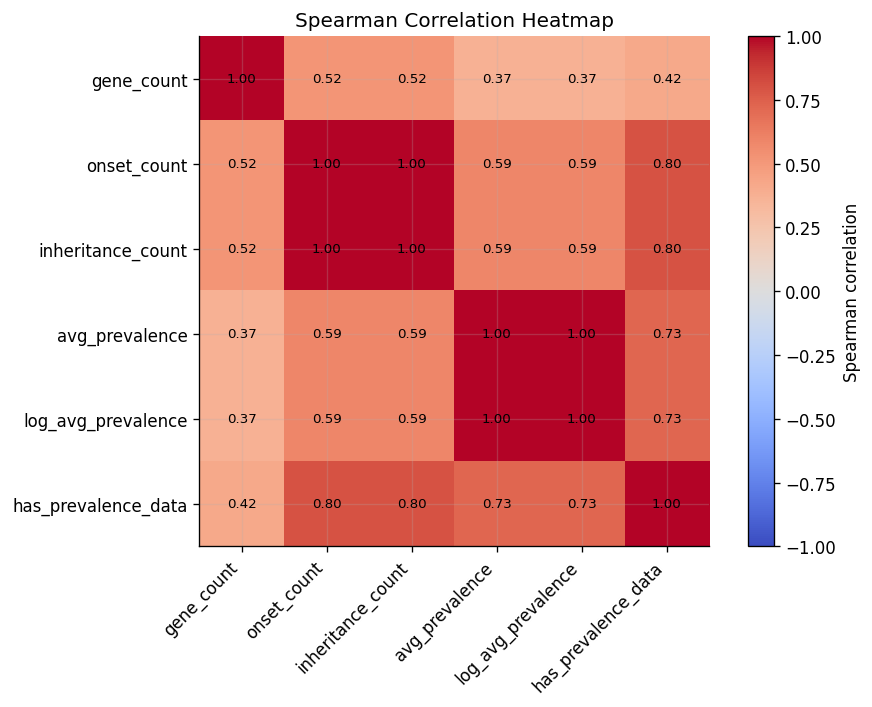

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

The heatmap shows onset_count and inheritance_count have a perfect correlation with each other of 1.00. This means diseases with onset information usually also contain inheritance information.

The analysis also shows moderate positive relationships between prevalence-related variables and clinical information. Gene_count has weaker relationships with the other variables which means it behaves differently from prevalence and clinical characteristics. This supports the idea that disease prioritization should consider multiple factors instead of relying on only one variable.

# 7. Feature Engineering

Using more analytic features to improve the modelling process and support disease prioritization. These new variables combine genetic, clinical, and prevalence-related information into a more structured format that can be used more effectively in clustering and machine learning models.

In [56]:
df["clinical_diversity_score"] = df["onset_count"] + df["inheritance_count"]
df["genetic_complexity_score"] = df["gene_count"]
df["prevalence_signal"] = df["log_avg_prevalence"]

df["has_gene_data"] = (df["gene_count"] > 0).astype(int)
df["has_onset_data"] = (df["onset_count"] > 0).astype(int)
df["has_inheritance_data"] = (df["inheritance_count"] > 0).astype(int)

df["data_completeness_score"] = (
    df["has_gene_data"] +
    df["has_onset_data"] +
    df["has_inheritance_data"] +
    df["has_prevalence_data"]
)

df[[
    "gene_count",
    "clinical_diversity_score",
    "prevalence_signal",
    "data_completeness_score"
]].describe().round(2)

,gene_count,clinical_diversity_score,prevalence_signal,data_completeness_score
count,11456.00,11456.00,11456.00,11456.00
mean,0.73,1.29,0.78,2.21
std,2.66,0.96,1.23,1.69
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,0.00,2.00,0.00,3.00
75%,1.00,2.00,1.25,4.00
max,114.00,2.00,9.21,4.00


This is the more structured view of the diseases by combining different types of information. The clinical_diversity_score mainly ranges between 0 and 2, showing that most diseases contain limited clinical detail related to onset and inheritance.
The data_completeness_score shows that many diseases still have incomplete information, while some diseases contain much richer data across multiple variables. This is important for prioritization because diseases with more complete and detailed information can support stronger analytical insights and decision-making.

## 8. Priority Score

In [58]:
priority_features = [
    "genetic_complexity_score",
    "clinical_diversity_score",
    "prevalence_signal",
    "data_completeness_score"
]

scaler_priority = MinMaxScaler()
priority_scaled = scaler_priority.fit_transform(df[priority_features])

priority_scaled_df = pd.DataFrame(
    priority_scaled,
    columns=[
        "genetic_complexity_scaled",
        "clinical_diversity_scaled",
        "prevalence_signal_scaled",
        "data_completeness_scaled"
    ],
    index=df.index
)

df = pd.concat([df, priority_scaled_df], axis=1)

df["priority_score"] = (
    0.35 * df["genetic_complexity_scaled"] +
    0.25 * df["clinical_diversity_scaled"] +
    0.30 * df["prevalence_signal_scaled"] +
    0.10 * df["data_completeness_scaled"]
)

df["priority_rank"] = df["priority_score"].rank(ascending=False, method="dense").astype(int)

df.sort_values("priority_score", ascending=False)[
    ["OrphaCode", "Name", "DisorderGroup", "gene_count", "avg_prevalence", "priority_score", "priority_rank"]
].head(20)

,OrphaCode,Name,DisorderGroup,gene_count,avg_prevalence,priority_score,priority_rank
705,791,Retinitis pigmentosa,Disorder,88,22.254444,0.722662,1
10252,528084,Non-specific syndromic intellectual disability,Disorder,114,0.000000,0.700000,2
6917,227972,Toxic oil syndrome,Disorder,0,10000.000000,0.625000,3
8603,319218,Ebola hemorrhagic fever,Disorder,0,9406.666667,0.623008,4
5572,103909,Trehalase deficiency,Disorder,1,3850.000000,0.621985,5
224,244,Primary ciliary dyskinesia,Disorder,53,24.500000,0.618209,6
9696,454745,Kuru,Disorder,1,1350.000000,0.587867,7
140,154,Familial isolated dilated cardiomyopathy,Disorder,53,8.803333,0.587072,8
3824,90636,Rare autosomal recessive non-syndromic sensori...,Subtype of disorder,74,0.000000,0.577193,9
1737,2309,Pachyonychia congenita,Disorder,4,500.045000,0.564769,10


The priority ranking identifies diseases with either high genetic complexity, high prevalence, or both. For example, Retinitis pigmentosa received the highest priority score because it contains a very large gene count (88) together with moderate prevalence values.

The ranking also highlights diseases such as Ebola hemorrhagic fever and Toxic oil syndrome, which achieved high scores mainly because of extremely large prevalence values despite having low gene counts. This shows that the prioritization framework does not rely on a single factor, but instead combines genetic, clinical, and prevalence-related information to identify diseases that may require greater analytical attention.

Distribution of Priority score

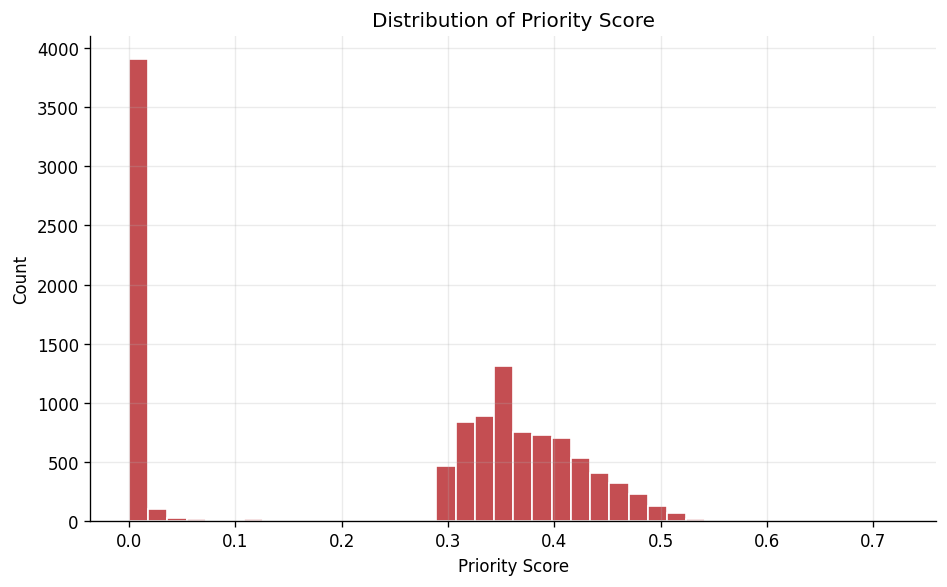

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df["priority_score"], bins=40, color="#C44E52", edgecolor="white")
plt.title("Distribution of Priority Score")
plt.xlabel("Priority Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("priority_score_distribution.png", bbox_inches="tight")
plt.show()

The priority score distribution shows that a large number of diseases received very low scores, while a smaller group of diseases achieved moderate to high priority scores. This indicates that only a limited number of diseases contain strong combinations of genetic complexity, prevalence, and clinical information.

## 9. Prepare Data for Modelling

Feature Scaling

Before clustering and modelling, numerical variables must be standardised to a similar scale so that features with larger numerical ranges do not dominate the models. Scaling is important in clustering because the algorithms rely heavily on distance calculations between data points.

In [23]:
model_features = [
    "gene_count",
    "onset_count",
    "inheritance_count",
    "log_avg_prevalence",
    "data_completeness_score"
]

X = df[model_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=model_features)
X_scaled_df.head()

,gene_count,onset_count,inheritance_count,log_avg_prevalence,data_completeness_score
0,0.102274,0.744021,0.744021,0.064624,1.060083
1,0.478404,0.744021,0.744021,0.124176,1.060083
2,1.230665,0.744021,0.744021,1.483002,1.060083
3,-0.273857,0.744021,0.744021,1.671486,0.467822
4,-0.273857,0.744021,0.744021,2.015490,0.467822


## 10. PCA Visualisation

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df["pc1"] = X_pca[:, 0]
df["pc2"] = X_pca[:, 1]

print("PC1 explained variance:", round(pca.explained_variance_ratio_[0], 4))
print("PC2 explained variance:", round(pca.explained_variance_ratio_[1], 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

PC1 explained variance: 0.6598
PC2 explained variance: 0.189
Total explained variance: 0.8488


The PCA results show that the first two principal components explain approximately 84.88% of the total variance in the dataset. The first component alone explains 65.98% of the variance, while the second component explains 18.90%.

This indicates that most of the important information in the dataset can be represented using two dimensions, making PCA suitable for visualising disease patterns and cluster structures more clearly.

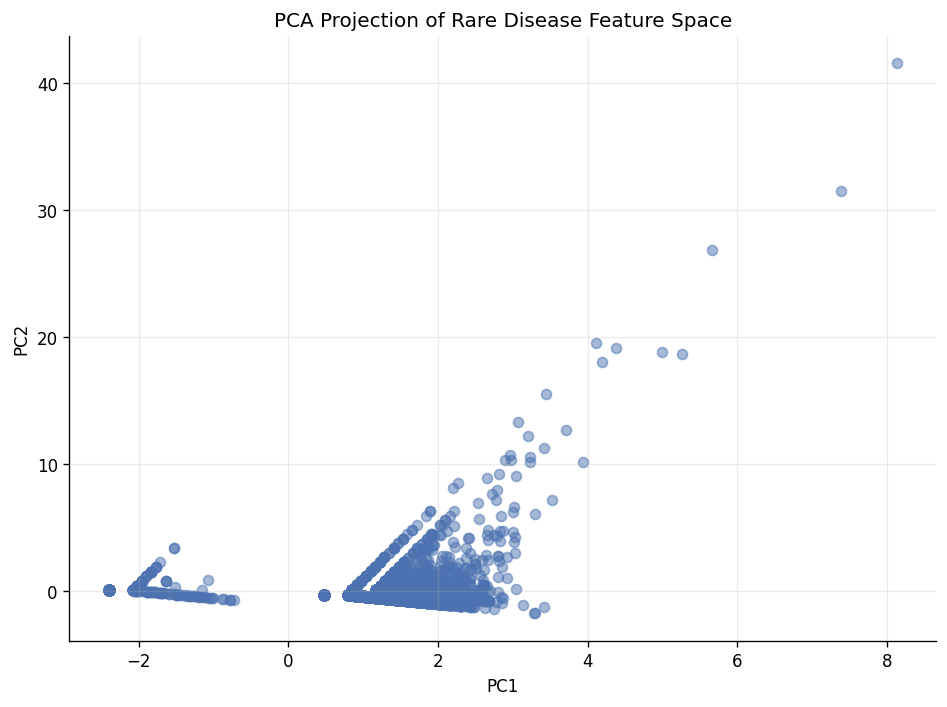

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(df["pc1"], df["pc2"], alpha=0.5, color="#4C72B0")
plt.title("PCA Projection of Rare Disease Feature Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("pca_unclustered.png", bbox_inches="tight")
plt.show()

Most of the diseases in the PCA plot sit close together in one tight cluster. A few diseases sit far away from the rest, which usually means they have something unusual about them — maybe they are much more common, have more genes involved, or simply have more detailed information recorded.

The plot also shows that the dataset is not random. There are real differences between diseases, which means clustering can be useful for finding groups of diseases that share similar features.

## 11. K-Means Clustering

In [26]:
k_range = range(2, 11)

inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

kmeans_metrics = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
    "davies_bouldin_score": db_scores,
    "calinski_harabasz_score": ch_scores
})

kmeans_metrics.round(4)

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,21178.9948,0.7319,0.3416,19524.1047
1,3,14593.9296,0.6775,0.6699,16749.6612
2,4,8723.0107,0.6813,0.6080,21249.3625
3,5,6412.9203,0.6915,0.5733,22707.2418
4,6,5069.8523,0.6265,0.6583,23582.7853
5,7,4255.6640,0.6313,0.6296,23775.2017
6,8,3583.9994,0.6225,0.6942,24502.2289
7,9,3156.2703,0.6187,0.7160,24545.9306
8,10,2802.2166,0.6216,0.7235,24724.5820


The clustering validation results show that the model performs best with a smaller number of clusters. The highest silhouette score of 0.7319 is achieved when k = 2, indicating strong separation between clusters.

As the number of clusters increases, the inertia value decreases from 21178.99 to 2802.22, which is expected because more clusters reduce within-group distance. However, the silhouette scores gradually decline after lower values of k, suggesting that too many clusters may create less meaningful group separation.

Overall, the validation metrics indicate that the dataset contains a few major disease patterns rather than many highly distinct groups.

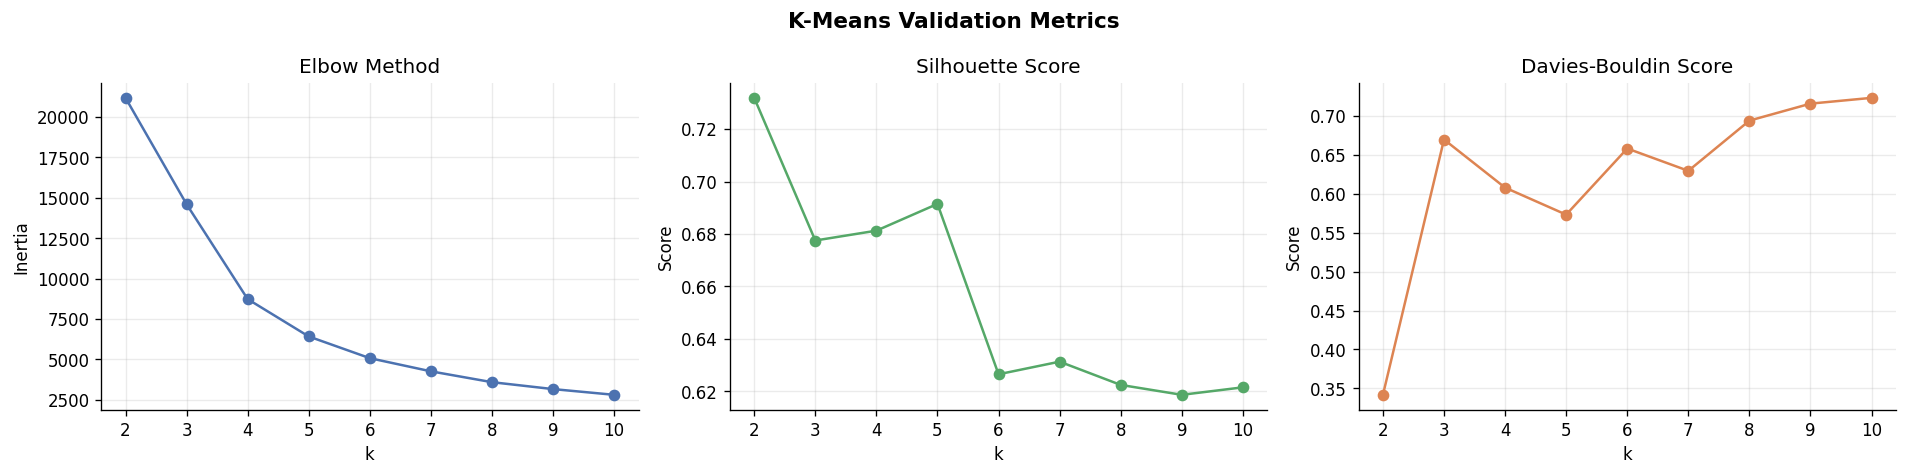

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("K-Means Validation Metrics", fontsize=13, fontweight="bold")

axes[0].plot(kmeans_metrics["k"], kmeans_metrics["inertia"], marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_metrics["k"], kmeans_metrics["silhouette_score"], marker="o", color="#55A868")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

axes[2].plot(kmeans_metrics["k"], kmeans_metrics["davies_bouldin_score"], marker="o", color="#DD8452")
axes[2].set_title("Davies-Bouldin Score")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.savefig("kmeans_validation_metrics.png", bbox_inches="tight")
plt.show()

The validation plots show that the clustering quality is strongest at lower values of k. The silhouette score reaches its highest value at k = 2 and remains relatively stable between k = 3 and k = 5, while the Davies-Bouldin score becomes worse as more clusters are added.

The elbow curve also shows a clear reduction in inertia between k = 2 and k = 4, after which the improvement becomes smaller. Based on these results, using around 4 clusters provides a reasonable balance between cluster separation and interpretability for the rare disease dataset.

In [28]:
selected_k = 4

kmeans = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=50)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means cluster sizes:")
display(df["kmeans_cluster"].value_counts().sort_index())

print("K-Means validation:")
print("Silhouette Score:", round(silhouette_score(X_scaled, df["kmeans_cluster"]), 4))
print("Davies-Bouldin Score:", round(davies_bouldin_score(X_scaled, df["kmeans_cluster"]), 4))
print("Calinski-Harabasz Score:", round(calinski_harabasz_score(X_scaled, df["kmeans_cluster"]), 4))

K-Means cluster sizes:


,count
kmeans_cluster,
0,2247
1,4077
2,5104
3,28


K-Means validation:
Silhouette Score: 0.6813
Davies-Bouldin Score: 0.608
Calinski-Harabasz Score: 21249.3625


The K-Means model divided the diseases into four clusters with different group sizes. Most diseases were grouped into clusters 1 and 2, containing 4,077 and 5,104 diseases respectively, while cluster 3 contained only 28 diseases.

The very small size of cluster 3 suggests that it may represent rare or unusual diseases with characteristics that are very different from the majority of the dataset. The silhouette score of 0.6813 also indicates that the clusters are reasonably well separated, meaning the model was able to identify meaningful patterns within the disease data.

In [29]:
kmeans_profile = df.groupby("kmeans_cluster")[
    ["gene_count", "onset_count", "inheritance_count", "avg_prevalence",
     "log_avg_prevalence", "data_completeness_score", "priority_score"]
].mean().round(3)

kmeans_profile

,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score
kmeans_cluster,,,,,,,
0,1.120,0.998,0.998,43.147,2.936,3.647,0.440
1,0.037,0.000,0.000,0.148,0.027,0.043,0.002
2,0.894,1.000,1.000,0.797,0.425,3.300,0.349
3,39.643,1.000,1.000,5.649,0.938,3.821,0.498


The cluster profiles show clear differences between disease groups. Cluster 1 mainly contains diseases with very little genetic, clinical, or prevalence information, resulting in the lowest average priority score 0.002.

In contrast, cluster 3 contains diseases with the highest average gene count 39.643 and the highest priority score 0.498, indicating genetically complex and analytically important diseases. Cluster 0 also shows high average prevalence values 43.147, representing diseases with stronger prevalence signals.

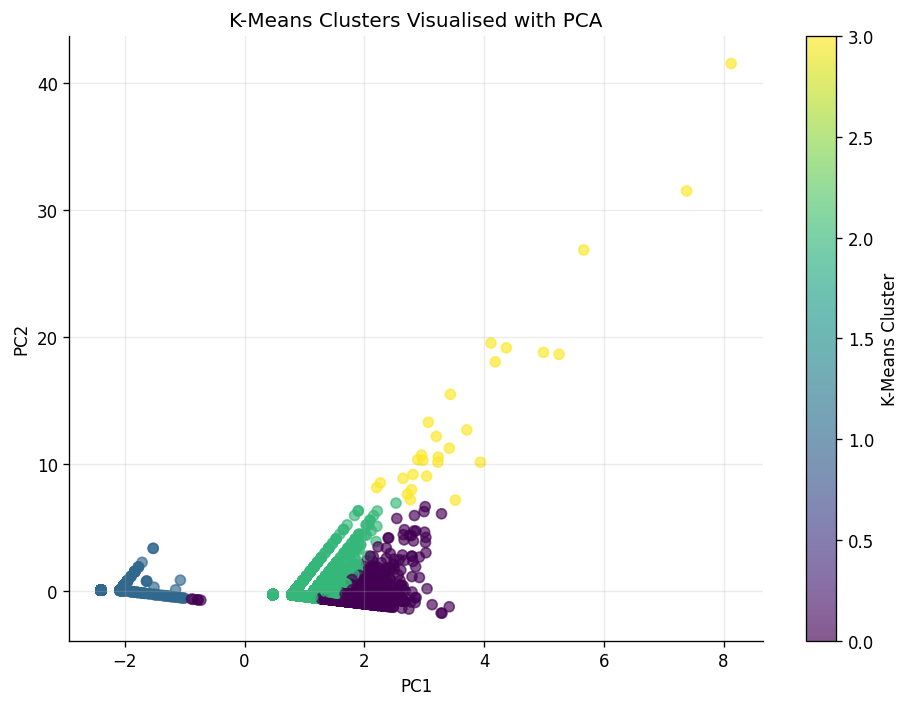

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(df["pc1"], df["pc2"], c=df["kmeans_cluster"], cmap="viridis", alpha=0.65)
plt.title("K-Means Clusters Visualised with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="K-Means Cluster")
plt.tight_layout()
plt.savefig("kmeans_pca_clusters.png", bbox_inches="tight")
plt.show()

The PCA visualisation shows that the K-Means model was able to separate the diseases into distinct groups within the feature space. Most diseases are concentrated in the central region, while a smaller cluster appears much farther from the main population, especially at higher PC2 values above 20.

These distant clusters likely represent diseases with unusually high prevalence values or greater genetic complexity, making them more analytically significant compared to the majority of diseases in the dataset.

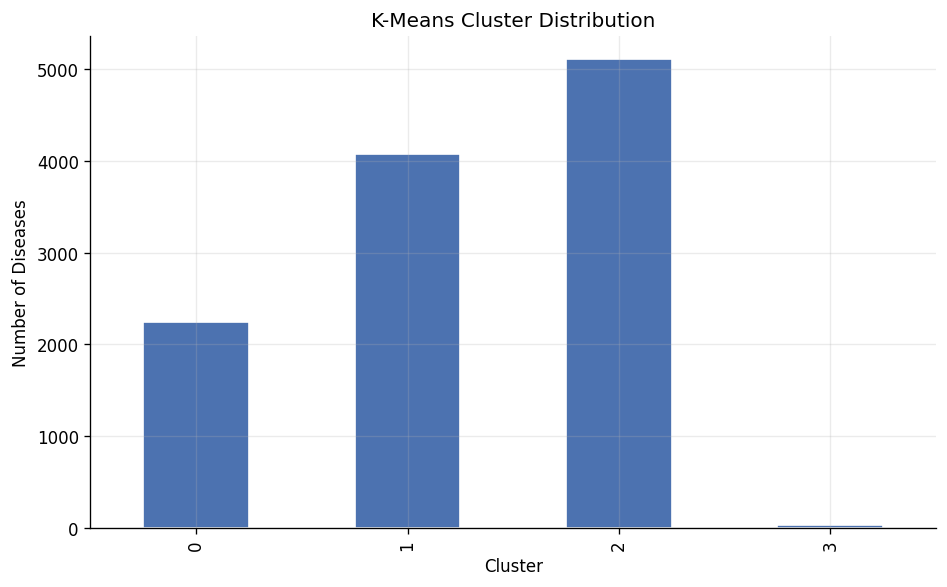

In [31]:
plt.figure(figsize=(8, 5))
df["kmeans_cluster"].value_counts().sort_index().plot(kind="bar", color="#4C72B0", edgecolor="white")
plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Diseases")
plt.tight_layout()
plt.savefig("kmeans_cluster_distribution.png", bbox_inches="tight")
plt.show()

The cluster distribution shows that most diseases are concentrated in clusters 1 and 2, containing more than 4,000 and 5,000 diseases respectively where as cluster 3 contains only a very small number of diseases. This means that the majority of diseases share similar characteristics while a small group of diseases behaves very differently from the rest which represent highly unique or important diseases.

## 12. Hierarchical Clustering

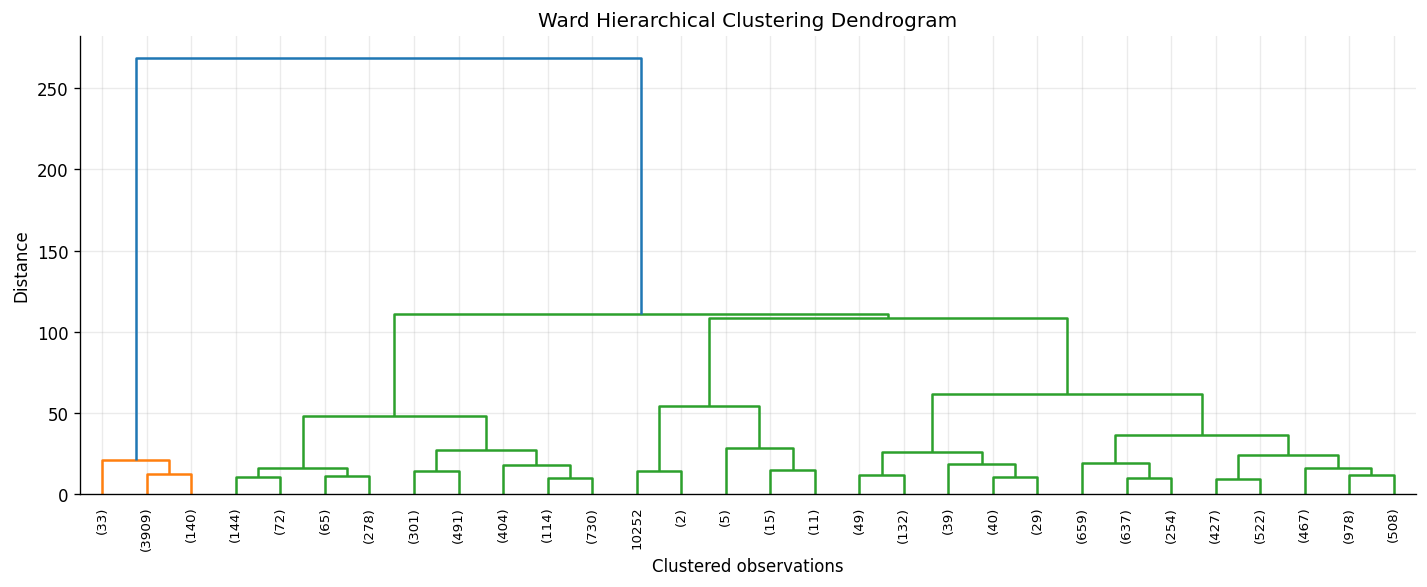

In [32]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8)
plt.title("Ward Hierarchical Clustering Dendrogram")
plt.xlabel("Clustered observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("hierarchical_dendrogram.png", bbox_inches="tight")
plt.show()

The hierarchical dendrogram shows that some diseases merge into clusters at very small distances, indicating strong similarity between their characteristics. However, a few branches merge only at much larger distances above 250, suggesting the presence of diseases that are very different from the majority of the dataset.

In [33]:
hierarchical = AgglomerativeClustering(n_clusters=selected_k, linkage="ward")
df["hierarchical_cluster"] = hierarchical.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
display(df["hierarchical_cluster"].value_counts().sort_index())

print("Hierarchical validation:")
print("Silhouette Score:", round(silhouette_score(X_scaled, df["hierarchical_cluster"]), 4))
print("Davies-Bouldin Score:", round(davies_bouldin_score(X_scaled, df["hierarchical_cluster"]), 4))
print("Calinski-Harabasz Score:", round(calinski_harabasz_score(X_scaled, df["hierarchical_cluster"]), 4))

Hierarchical cluster sizes:


,count
hierarchical_cluster,
0,4741
1,34
2,2599
3,4082


Hierarchical validation:
Silhouette Score: 0.6643
Davies-Bouldin Score: 0.6354
Calinski-Harabasz Score: 20071.6464


The hierarchical clustering model grouped most diseases into larger clusters, while one cluster contained only 34 diseases. This small cluster likely represents diseases with characteristics that are very different from the majority of the dataset.

The silhouette score of 0.6643 indicates reasonably good cluster separation, although the performance is slightly lower than the K-Means model. Overall, the results show that hierarchical clustering was also able to identify meaningful disease groupings within the dataset.

In [34]:
hierarchical_profile = df.groupby("hierarchical_cluster")[
    ["gene_count", "onset_count", "inheritance_count", "avg_prevalence",
     "log_avg_prevalence", "data_completeness_score", "priority_score"]
].mean().round(3)

hierarchical_profile

,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score
hierarchical_cluster,,,,,,,
0,0.995,1.0,1.0,0.900,0.361,3.276,0.347
1,35.971,1.0,1.0,6.914,1.162,3.853,0.495
2,0.865,1.0,1.0,36.987,2.701,3.646,0.432
3,0.037,0.0,0.0,0.282,0.033,0.044,0.002


The hierarchical cluster profiles show clear differences between the disease groups. Cluster 1 contains diseases with the highest average gene count 35.971 and the highest priority score 0.495, indicating genetically complex and analytically important diseases.

Cluster 2 shows much higher prevalence values 36.987 compared to the other groups, while cluster 3 contains diseases with almost no genetic, clinical, or prevalence information, resulting in the lowest average priority score 0.002. This suggests that the clustering model successfully separated high-information diseases from lower-information disease groups.

## 13. Comparing K-Means and Hierarchical Clustering

In [35]:
cluster_comparison = pd.crosstab(df["kmeans_cluster"], df["hierarchical_cluster"])
cluster_comparison

hierarchical_cluster,0,1,2,3
kmeans_cluster,,,,
0,63,5,2174,5
1,0,0,0,4077
2,4678,1,425,0
3,0,28,0,0


The comparison between K-Means and hierarchical clustering shows that both models identified several similar disease group patterns. For example, most diseases from K-Means cluster 1 were grouped into hierarchical cluster 3 (4,077 diseases), showing strong agreement between the two methods.

However, some clusters were divided differently between the models, especially for diseases with higher prevalence or genetic complexity. This suggests that both clustering techniques captured similar overall structures, while still detecting some unique grouping patterns within the dataset.

In [36]:
ari = adjusted_rand_score(df["kmeans_cluster"], df["hierarchical_cluster"])
nmi = normalized_mutual_info_score(df["kmeans_cluster"], df["hierarchical_cluster"])

print("Adjusted Rand Index:", round(ari, 4))
print("Normalized Mutual Information:", round(nmi, 4))

Adjusted Rand Index: 0.8874
Normalized Mutual Information: 0.8627


The clustering comparison produced a high Adjusted Rand Index of 0.8874 and a high Normalized Mutual Information score of 0.8627. This suggests that both techniques identified very similar disease group patterns, increasing the reliability and consistency of the clustering results.

## 14. Gaussian Mixture Model

In [37]:
gmm_results = []

for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=10)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)

    gmm_results.append({
        "k": k,
        "aic": gmm.aic(X_scaled),
        "bic": gmm.bic(X_scaled),
        "silhouette_score": silhouette_score(X_scaled, labels)
    })

gmm_metrics = pd.DataFrame(gmm_results)
gmm_metrics.round(4)

,k,aic,bic,silhouette_score
0,2,-221197.5634,-220896.3664,0.7319
1,3,-360091.6872,-359636.2185,0.7049
2,4,-371282.6529,-370672.9126,0.5865
3,5,-440415.4961,-439651.4841,0.4676
4,6,-487326.0034,-486407.7198,0.3755
5,7,-479877.7448,-478805.1896,0.3869
6,8,-526221.6882,-524994.8613,0.4216


The Gaussian Mixture Model results show that lower cluster values produced stronger cluster separation. The highest silhouette score (0.7319) was achieved at k = 2, and the score decreased as more clusters were added.

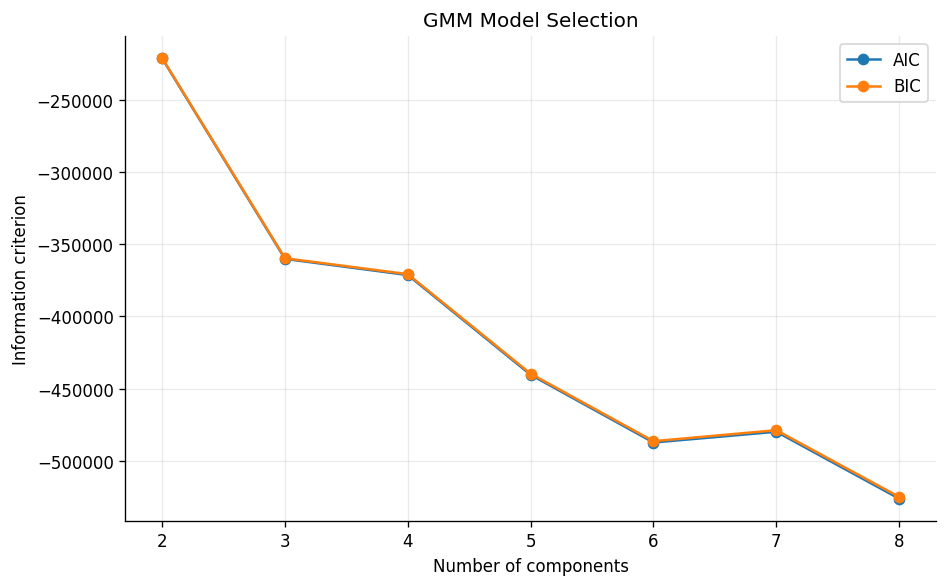

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(gmm_metrics["k"], gmm_metrics["aic"], marker="o", label="AIC")
plt.plot(gmm_metrics["k"], gmm_metrics["bic"], marker="o", label="BIC")
plt.title("GMM Model Selection")
plt.xlabel("Number of components")
plt.ylabel("Information criterion")
plt.legend()
plt.tight_layout()
plt.savefig("gmm_model_selection.png", bbox_inches="tight")
plt.show()

The GMM model selection plot shows that both AIC and BIC values generally decrease as the number of components increases, indicating improved statistical fit with more complex models. The largest improvement occurs between k = 2 and k = 5, after which the reduction becomes smaller.
This suggests that adding a few clusters improves the model significantly, but too many components may increase complexity without creating clearly meaningful disease groups.

In [39]:
best_gmm_k = int(gmm_metrics.loc[gmm_metrics["bic"].idxmin(), "k"])
print("Selected GMM components based on BIC:", best_gmm_k)

gmm = GaussianMixture(n_components=best_gmm_k, random_state=RANDOM_STATE, n_init=20)
df["gmm_cluster"] = gmm.fit_predict(X_scaled)

gmm_probabilities = gmm.predict_proba(X_scaled)
df["gmm_membership_confidence"] = gmm_probabilities.max(axis=1)

df["gmm_cluster"].value_counts().sort_index()

Selected GMM components based on BIC: 8


,count
gmm_cluster,
0,1309
1,2594
2,3909
3,2019
4,94
5,173
6,891
7,467


The Gaussian Mixture Model selected 8 components based on the lowest BIC value. Most diseases were grouped into larger clusters, while a few smaller clusters contained fewer than 100 diseases.

This suggests that the model identified both broad disease patterns and smaller groups with more unique characteristics.

In [40]:
gmm_profile = df.groupby("gmm_cluster")[
    ["gene_count", "onset_count", "inheritance_count", "avg_prevalence",
     "log_avg_prevalence", "data_completeness_score", "priority_score",
     "gmm_membership_confidence"]
].mean().round(3)

gmm_profile

,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score,gmm_membership_confidence
gmm_cluster,,,,,,,,
0,0.411,1.0,1.0,0.000,0.000,3.000,0.326,0.851
1,1.000,1.0,1.0,12.949,1.549,4.000,0.404,1.000
2,0.000,0.0,0.0,0.000,0.000,0.000,0.000,1.000
3,0.000,1.0,1.0,26.824,1.699,3.000,0.380,1.000
4,7.819,1.0,1.0,0.000,0.000,3.000,0.349,0.998
5,0.879,0.0,0.0,6.649,0.768,1.035,0.054,1.000
6,4.851,1.0,1.0,14.461,1.487,4.000,0.413,1.000
7,0.000,1.0,1.0,0.000,0.000,2.000,0.300,1.000


The GMM cluster profiles show noticeable differences between disease groups. Cluster 6 achieved the highest average priority score (0.413), while cluster 2 contained diseases with almost no genetic, clinical, or prevalence information, resulting in a priority score of 0.000.

Clusters 1 and 3 also showed higher prevalence values, indicating disease groups with stronger prevalence signals and better data completeness.

## 15. Isolation Forest Anomaly Detection

In [41]:
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=RANDOM_STATE
)

df["anomaly_label"] = isolation_model.fit_predict(X_scaled)
df["anomaly_score"] = isolation_model.decision_function(X_scaled)
df["is_anomaly"] = (df["anomaly_label"] == -1).astype(int)

df["is_anomaly"].value_counts()

,count
is_anomaly,
0,11341
1,115


The Isolation Forest model identified 115 diseases as anomalies out of 11,456 total diseases. This indicates that only a small proportion of diseases show highly unusual patterns compared to the overall dataset.

These anomalies may represent diseases with exceptionally high prevalence values, unusual genetic complexity, or uncommon clinical characteristics.

In [42]:
anomaly_profile = df.groupby("is_anomaly")[
    ["gene_count", "onset_count", "inheritance_count", "avg_prevalence",
     "log_avg_prevalence", "data_completeness_score", "priority_score"]
].mean().round(3)

anomaly_profile

,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score
is_anomaly,,,,,,,
0,0.610,0.647,0.647,8.824,0.769,2.212,0.244
1,12.417,0.357,0.357,14.902,1.552,2.043,0.229


In [43]:
top_anomalies = df.sort_values("anomaly_score").head(25)[
    ["OrphaCode", "Name", "DisorderGroup", "gene_count", "onset_count",
     "inheritance_count", "avg_prevalence", "priority_score",
     "kmeans_cluster", "is_anomaly", "anomaly_score"]
]

top_anomalies

,OrphaCode,Name,DisorderGroup,gene_count,onset_count,inheritance_count,avg_prevalence,priority_score,kmeans_cluster,is_anomaly,anomaly_score
10744,642976,Perrault syndrome type 2,Subtype of disorder,9,0,0,0.000000,0.052632,1,1,-0.048292
10741,642945,Perrault syndrome type 1,Subtype of disorder,9,0,0,0.000000,0.052632,1,1,-0.048292
705,791,Retinitis pigmentosa,Disorder,88,1,1,22.254444,0.722662,3,1,-0.046550
224,244,Primary ciliary dyskinesia,Disorder,53,1,1,24.500000,0.618209,3,1,-0.041909
2506,3388,Neural tube defect,Group of disorders,0,0,0,141.656522,0.186570,0,1,-0.041340
480,536,Systemic lupus erythematosus,Disorder,30,1,1,35.980000,0.559702,3,1,-0.040127
10964,664787,Nicolau syndrome,Disorder,0,0,0,120.000000,0.181207,0,1,-0.039989
3702,88991,Rare congenital non-syndromic heart malformation,Group of disorders,0,0,0,115.400000,0.179945,0,1,-0.036623
6262,178342,Inflammatory myofibroblastic tumor,Disorder,6,0,0,0.000000,0.043421,1,1,-0.036140
11005,675396,Epithelioid hemangioma,Disorder,5,0,0,0.000000,0.040351,1,1,-0.032422


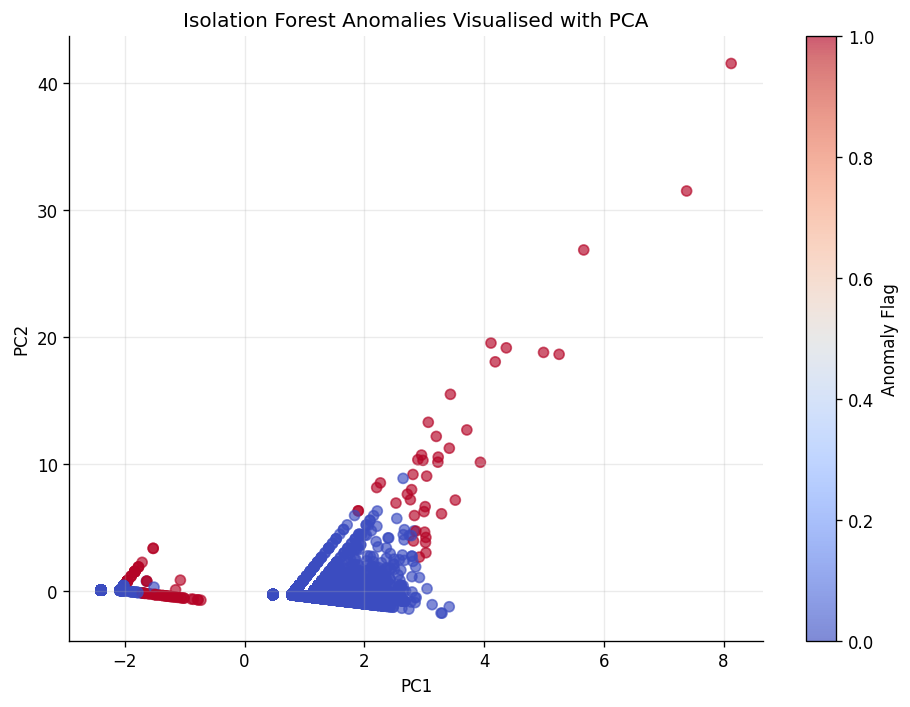

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(df["pc1"], df["pc2"], c=df["is_anomaly"], cmap="coolwarm", alpha=0.65)
plt.title("Isolation Forest Anomalies Visualised with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Anomaly Flag")
plt.tight_layout()
plt.savefig("isolation_forest_anomalies.png", bbox_inches="tight")
plt.show()

The most diseases are concentrated within the normal feature space, while only a few diseases appear isolated from the main population. These isolated diseases represent unusual cases that differ significantly from the majority of diseases in terms of prevalence, genetic complexity, or clinical information.

## 16. Supporting Regression Benchmark

In [45]:
reg_features = ["gene_count", "onset_count", "inheritance_count", "data_completeness_score"]
target = "avg_prevalence"

X_reg = df[reg_features]
y_reg = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

regression_results = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ]
})

regression_results.round(4)

,model,MAE,RMSE,R2
0,Linear Regression,14.6653,199.7250,0.0012
1,Random Forest Regressor,14.4503,199.6007,0.0025


The Random Forest model performed slightly better than Linear Regression, achieving a lower MAE (14.4503) and RMSE (199.6007). However, both models produced very low R² values, indicating that the selected features explain only a small portion of the variation in prevalence values.

In [46]:
feature_importance = pd.DataFrame({
    "feature": reg_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
3,data_completeness_score,0.812541
0,gene_count,0.186592
2,inheritance_count,0.000490
1,onset_count,0.000377


The results show that data_completeness_score was the most influential variable in the Random Forest model, contributing approximately 81.25% of the total importance.Gene_count contributed around 18.66%, while onset_count and inheritance_count had very little influence on prevalence prediction.

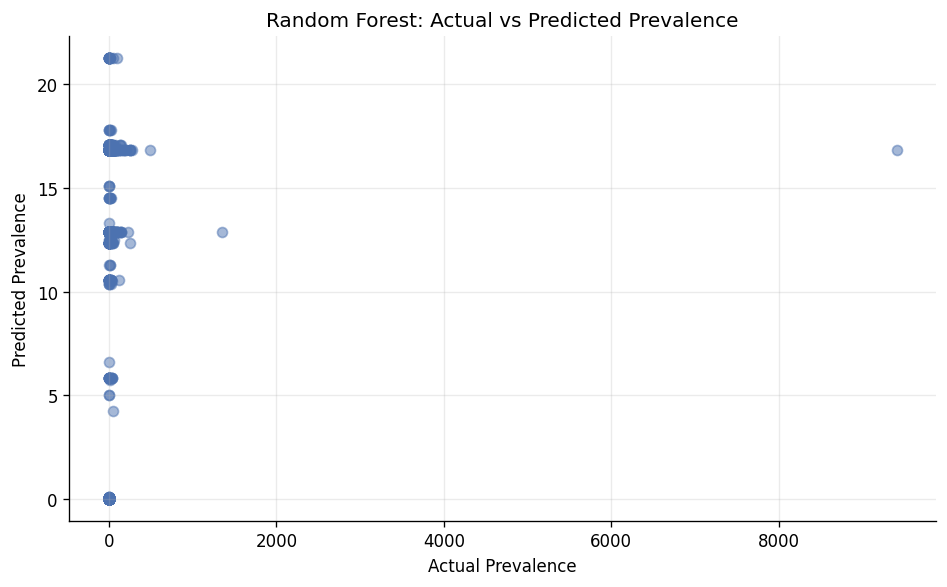

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.5, color="#4C72B0")
plt.title("Random Forest: Actual vs Predicted Prevalence")
plt.xlabel("Actual Prevalence")
plt.ylabel("Predicted Prevalence")
plt.tight_layout()
plt.savefig("rf_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

The scatterplot shows that the Random Forest model was able to predict lower prevalence values more consistently, while prediction accuracy decreased for diseases with extremely high prevalence values.Several diseases with very large actual prevalence values appear far from the main concentration of points, indicating the presence of strong outliers within the dataset.

## 17. Final Prioritization Table

In [48]:
df["priority_segment"] = pd.cut(
    df["priority_score"],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.00],
    labels=["Low Priority", "Moderate Priority", "High Priority", "Critical Priority"]
)

final_columns = [
    "OrphaCode", "Name", "DisorderGroup",
    "gene_count", "onset_count", "inheritance_count",
    "avg_prevalence", "log_avg_prevalence",
    "has_prevalence_data", "data_completeness_score",
    "priority_score", "priority_rank", "priority_segment",
    "kmeans_cluster", "hierarchical_cluster", "gmm_cluster",
    "gmm_membership_confidence", "is_anomaly", "anomaly_score"
]

final_df = df[final_columns].sort_values("priority_rank")
final_df.head(30)

,OrphaCode,Name,DisorderGroup,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,has_prevalence_data,data_completeness_score,priority_score,priority_rank,priority_segment,kmeans_cluster,hierarchical_cluster,gmm_cluster,gmm_membership_confidence,is_anomaly,anomaly_score
705,791,Retinitis pigmentosa,Disorder,88,1,1,22.254444,3.146496,1,4,0.722662,1,High Priority,3,1,6,1.000000,1,-0.046550
10252,528084,Non-specific syndromic intellectual disability,Disorder,114,1,1,0.000000,0.000000,1,4,0.700000,2,High Priority,3,1,6,1.000000,1,-0.031410
6917,227972,Toxic oil syndrome,Disorder,0,1,1,10000.000000,9.210440,1,3,0.625000,3,High Priority,0,2,3,1.000000,0,0.042558
8603,319218,Ebola hemorrhagic fever,Disorder,0,1,1,9406.666667,9.149280,1,3,0.623008,4,High Priority,0,2,3,1.000000,0,0.042558
5572,103909,Trehalase deficiency,Disorder,1,1,1,3850.000000,8.256088,1,4,0.621985,5,High Priority,0,2,1,0.995318,0,0.058357
224,244,Primary ciliary dyskinesia,Disorder,53,1,1,24.500000,3.238678,1,4,0.618209,6,High Priority,3,1,6,1.000000,1,-0.041909
9696,454745,Kuru,Disorder,1,1,1,1350.000000,7.208600,1,4,0.587867,7,High Priority,0,2,1,0.998512,0,0.062607
140,154,Familial isolated dilated cardiomyopathy,Disorder,53,1,1,8.803333,2.282722,1,4,0.587072,8,High Priority,3,1,6,1.000000,1,-0.030746
3824,90636,Rare autosomal recessive non-syndromic sensori...,Subtype of disorder,74,1,1,0.000000,0.000000,1,4,0.577193,9,High Priority,3,1,6,1.000000,1,-0.026722
1737,2309,Pachyonychia congenita,Disorder,4,1,1,500.045000,6.216696,1,4,0.564769,10,High Priority,0,2,6,1.000000,0,0.014597


In [49]:
priority_summary = final_df.groupby("priority_segment", observed=False).agg(
    disease_count=("OrphaCode", "count"),
    avg_gene_count=("gene_count", "mean"),
    avg_prevalence=("avg_prevalence", "mean"),
    avg_priority_score=("priority_score", "mean"),
    anomaly_count=("is_anomaly", "sum")
).round(3)

priority_summary

,disease_count,avg_gene_count,avg_prevalence,avg_priority_score,anomaly_count
priority_segment,,,,,
Low Priority,4082,0.037,0.282,0.002,74
Moderate Priority,7235,1.013,7.415,0.375,25
High Priority,139,6.180,338.012,0.523,16
Critical Priority,0,NaN,NaN,NaN,0


In [50]:
cluster_summary = final_df.groupby("kmeans_cluster").agg(
    disease_count=("OrphaCode", "count"),
    avg_gene_count=("gene_count", "mean"),
    avg_prevalence=("avg_prevalence", "mean"),
    avg_priority_score=("priority_score", "mean"),
    anomaly_count=("is_anomaly", "sum")
).round(3)

cluster_summary

,disease_count,avg_gene_count,avg_prevalence,avg_priority_score,anomaly_count
kmeans_cluster,,,,,
0,2247,1.120,43.147,0.440,16
1,4077,0.037,0.148,0.002,69
2,5104,0.894,0.797,0.349,3
3,28,39.643,5.649,0.498,27


## 18. Export Outputs for Power BI and Report

In [51]:
final_df.to_csv("rare_diseases_final_prioritization_dataset.csv", index=False)
priority_summary.to_csv("priority_summary.csv")
cluster_summary.to_csv("cluster_summary.csv")
kmeans_metrics.to_csv("kmeans_validation_metrics.csv", index=False)
gmm_metrics.to_csv("gmm_validation_metrics.csv", index=False)
regression_results.to_csv("regression_results.csv", index=False)

print("Exported files:")
print("- rare_diseases_final_prioritization_dataset.csv")
print("- priority_summary.csv")
print("- cluster_summary.csv")
print("- kmeans_validation_metrics.csv")
print("- gmm_validation_metrics.csv")
print("- regression_results.csv")

Exported files:
- rare_diseases_final_prioritization_dataset.csv
- priority_summary.csv
- cluster_summary.csv
- kmeans_validation_metrics.csv
- gmm_validation_metrics.csv
- regression_results.csv


In [52]:
import os

os.listdir()

['.config',
 'priority_summary.csv',
 'kmeans_cluster_distribution.png',
 'gmm_validation_metrics.csv',
 'rare_diseases_final_prioritization_dataset.csv',
 'priority_score_distribution.png',
 'kmeans_validation_metrics.png',
 'correlation_heatmap.png',
 'cluster_summary.csv',
 'regression_results.csv',
 'kmeans_validation_metrics.csv',
 'eda_main_distributions.png',
 'rf_actual_vs_predicted.png',
 'gmm_model_selection.png',
 'pca_unclustered.png',
 'hierarchical_dendrogram.png',
 'kmeans_pca_clusters.png',
 'log_prevalence_distribution.png',
 'disorder_group_distribution.png',
 'isolation_forest_anomalies.png',
 'sample_data']